In [24]:
import pandas as pd
import re
import os
import pandas as pd
import plots
import matplotlib.pyplot as plt

try:
    from tqdm.notebook import tqdm
except Exception:
    from tqdm import tqdm


from sqlalchemy import create_engine, text
from sqlalchemy.exc import SQLAlchemyError
try:
    from google.colab import userdata
    get_secret = userdata.get
except ImportError:
    # Fallback: define a dummy get_secret for local use
    def get_secret(key):
        return None

def get_env(key: str, default: str = None):
    """Tries os.getenv first, then Colab userdata if available."""
    return os.getenv(key) or get_secret(key) or default


DB_HOST = get_env("POSTGRES_DB_HOST")
DB_PORT = int(get_env("POSTGRES_DB_PORT"))
DB_NAME = get_env("POSTGRES_DB_NAME")
DB_USER = get_env("POSTGRES_DB_USER")
DB_PASS = get_env("POSTGRES_DB_PASS")

connection_url = f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(connection_url, echo=False)

In [25]:
scores_df = pd.read_sql("""select scores4.*, policy_splits.split_label from scores4
JOIN policy_splits on scores4.policy_id =  policy_splits.policy_id
WHERE policy_splits.split_label = 'test' and model_name <> 'v3.7'
UNION ALL 
select scores6.*, policy_splits.split_label from scores6
JOIN policy_splits on scores6.policy_id =  policy_splits.policy_id
WHERE policy_splits.split_label = 'test' and model_name = 'v3.7'""", engine)

In [37]:
import numpy as np
import pandas as pd

def safe(x, eps=1e-6):
    """Clamp to at least eps; works for scalars, Series, ndarrays."""
    return np.maximum(x, eps)

def add_pillars_and_mds(scores_df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds:
      - S_coverage
      - S_sem_faith
      - S_surface
      - S_MDS  (weighted harmonic mean of the three pillars)

    Returns a new DataFrame with these columns.
    """

    df = scores_df.copy()

    # --- 1) Coverage pillar ---
    # pick ONE consistent definition; using your latest (0.25, 0.30, 0.30, 0.15)
    df["S_coverage"] = (
        0.25 * df["S_keyword"] +
        0.30 * df["S_ontology_direct"] +
        0.30 * df["S_ontology_inferred"] +
        0.15 * df["S_ontology"]
    )

    # --- 2) Semantic + faithfulness pillar ---
    df["S_sem_faith"] = (
        0.40 * df["S_sem"] +
        0.40 * df["S_ragas_faithfulness"] +
        0.20 * df["S_ragas_relevancy"]
    )

    # --- 3) Surface pillar ---
    if "S_spacy" in df.columns:
        df["S_surface"] = (
            0.40 * df["S_lex"] +
            0.30 * df["S_len"] +
            0.30 * df["S_spacy"]
        )
    else:
        df["S_surface"] = 0.5 * df["S_lex"] + 0.5 * df["S_len"]

    # --- 4) MDS: weighted harmonic mean of the three pillars ---
    # weights: coverage 0.35, semantic 0.45, surface 0.20
    w_cov, w_sem, w_surf = 0.35, 0.45, 0.20

    denom = (
        w_cov  / safe(df["S_coverage"]) +
        w_sem  / safe(df["S_sem_faith"]) +
        w_surf / safe(df["S_surface"])
    )

    df["S_MDS"] = 1.0 / denom

    return df


In [35]:
def build_mds_summary_tables(
    scores_df: pd.DataFrame,
    models=("v2.5", "v3.7"),
    split: str = "test",
    split_label_col: str = "split_label",
    model_col: str = "model_name",
    metrics=None,
):
    """
    Assumes scores_df already has columns:
      S_MDS, S_coverage, S_sem_faith, S_surface, etc.
    Returns: table1, table2, table3
    """

    if metrics is None:
        metrics = [
            "S_MDS",
            "S_coverage",
            "S_sem_faith",
            "S_surface",
            "S_sem",
            "S_len",
            "S_ontology",
            "S_ragas",
        ]

    df = scores_df[scores_df[split_label_col] == split].copy()
    m1, m2, m3, m4 = models

    def cohens_d(x, y):
        x = x.dropna()
        y = y.dropna()
        nx, ny = len(x), len(y)
        if nx < 2 or ny < 2:
            return np.nan
        pooled_sd = np.sqrt(
            ((nx-1)*x.std(ddof=1)**2 + (ny-1)*y.std(ddof=1)**2) / (nx+ny-2)
        )
        if pooled_sd == 0:
            return np.nan
        return (y.mean() - x.mean()) / pooled_sd

    # ---------- Table 1: means / medians ----------
    rows1 = []
    for metric in metrics:
        v1 = df[df[model_col] == m1][metric]
        v2 = df[df[model_col] == m2][metric]
        v3 = df[df[model_col] == m3][metric]
        v4 = df[df[model_col] == m4][metric]
        rows1.append({
            "Metric": metric,
            f"{m1}_mean":   v1.mean(),
            f"{m2}_mean":   v2.mean(),
            f"{m3}_mean":   v3.mean(),
            f"{m4}_mean":   v4.mean(),
            f"Δ_mean: {m1} vs {m2}":       v2.mean() - v1.mean(),
            f"Δ_mean: {m2} vs {m3}":     v3.mean() - v2.mean(),
            f"Δ_mean: {m3} vs {m4}":     v4.mean() - v3.mean(),
            f"Δ_mean: {m1} vs {m4}":     v4.mean() - v1.mean(),
            f"{m1}_median": v1.median(),
            f"{m2}_median": v2.median(),
            f"{m3}_median": v3.median(),
            f"{m4}_median": v4.median(),
            f"Δ_median: {m1} vs {m2}":     v2.median() - v1.median(),
            f"Δ_median: {m1} vs {m3}":   v3.median() - v1.median(),
            f"Δ_median: {m1} vs {m4}":   v4.median() - v1.median(),
            
        })
    table1 = pd.DataFrame(rows1)

    # ---------- Table 2: percentiles ----------
    rows2 = []
    for metric in metrics:
        v1 = df[df[model_col] == m1][metric]
        v2 = df[df[model_col] == m2][metric]
        rows2.append({
            "Metric": metric,
            f"{m1}_p10": np.percentile(v1, 10),
            f"{m2}_p10": np.percentile(v2, 10),
            f"{m3}_p10": np.percentile(v3, 10),
            f"{m4}_p10": np.percentile(v4, 10),
            f"{m1}_p50": np.percentile(v1, 50),
            f"{m2}_p50": np.percentile(v2, 50),
            f"{m3}_p50": np.percentile(v3, 50),
            f"{m4}_p50": np.percentile(v4, 50),
            f"{m1}_p90": np.percentile(v1, 90),
            f"{m2}_p90": np.percentile(v2, 90),
            f"{m3}_p90": np.percentile(v3, 90),
            f"{m4}_p90": np.percentile(v4, 90),
        })
    table2 = pd.DataFrame(rows2)

    # ---------- Table 3: Cohen's d ----------
    rows3 = []
    for metric in metrics:
        v1 = df[df[model_col] == m1][metric]
        v2 = df[df[model_col] == m2][metric]
        rows3.append({
            "Metric": metric,
            f"Cohen_d: {m1} vs {m2}": cohens_d(v1, v2),
            f"Cohen_d: {m2} vs {m3}": cohens_d(v2, v3),
            f"Cohen_d: {m3} vs {m4}": cohens_d(v3, v4),
            f"Cohen_d: {m1} vs {m4}": cohens_d(v1, v4),
        })
    table3 = pd.DataFrame(rows3)

    return table1, table2, table3


In [28]:
scores_with_pillars = add_pillars_and_mds(scores_df)


In [42]:
def summarize_baseline(df, metric_names):
    rows = []
    
    for metric in metric_names:
        if metric not in df.columns:
            continue
        
        for model, g in df.groupby("model_name"):
            vals = g[metric].dropna().astype(float).values
            
            rows.append({
                "model": model,
                "metric": metric,
                "mean": vals.mean(),
                "median": np.median(vals),
                "std": vals.std(ddof=1),
                "p25": np.percentile(vals, 25),
                "p75": np.percentile(vals, 75),
                "n": len(vals),
            })
    
    return pd.DataFrame(rows)

metric_names = [
    "S_coverage",
    "S_sem_faith",
    "S_surface",
    "S_MDS",
    

]
summary_df = summarize_baseline(scores_with_pillars, metric_names)
median_table = (
    summary_df
    .pivot(index="model", columns="metric", values="median")
    .reindex(columns=metric_names)   # keep your order
    .round(3)
)
median_table = median_table.sort_values("model", ascending=True)

median_table

metric,S_coverage,S_sem_faith,S_surface,S_MDS
model,,,,
Gemma-2-9B,0.541,0.412,0.480,0.470
Llama-3.2-3B-Instruct,0.716,0.396,0.452,0.468
Mistral-7B-Instruct-v0.3,0.812,0.377,0.454,0.491
SmolLM3,0.511,0.393,0.446,0.443
v1.5,0.770,0.670,0.489,0.638
v2.5,0.796,0.742,0.457,0.664
v3.7,0.785,0.510,0.493,0.562
v4.0,0.786,0.466,0.501,0.557


In [30]:
median_table

metric,S_lex,S_len,S_keyword
model,,,
Gemma-2-9B,0.146,0.444,0.266
Llama-3.2-3B-Instruct,0.137,0.356,0.302
Mistral-7B-Instruct-v0.3,0.130,0.371,0.275
SmolLM3,0.144,0.318,0.263
v1.5,0.150,0.455,0.275
v2.5,0.131,0.379,0.282
v3.7,0.145,0.484,0.173
v4.0,0.151,0.492,0.185


In [31]:
summary_df

,model,metric,mean,median,std,p25,p75,n
0,Gemma-2-9B,S_lex,0.143254,0.145948,0.029631,0.127915,0.151569,24
1,Llama-3.2-3B-Instruct,S_lex,0.147392,0.137457,0.050031,0.115226,0.168224,53
2,Mistral-7B-Instruct-v0.3,S_lex,0.131505,0.129505,0.020419,0.119849,0.150771,24
3,SmolLM3,S_lex,0.144507,0.143627,0.030833,0.118301,0.164108,24
4,v1.5,S_lex,0.152409,0.149830,0.047839,0.121226,0.176692,142
5,v2.5,S_lex,0.135811,0.131028,0.035150,0.110719,0.157040,142
6,v3.7,S_lex,0.176219,0.144928,0.130114,0.116912,0.184989,142
7,v4.0,S_lex,0.184158,0.150796,0.133449,0.119939,0.191455,142
8,Gemma-2-9B,S_len,0.435018,0.443765,0.162723,0.306303,0.502988,24
9,Llama-3.2-3B-Instruct,S_len,0.383461,0.355907,0.200752,0.228924,0.490126,53


In [ ]:
split_label[split_label['split_label'] == 'test']

In [40]:
scores_with_pillars.columns

Index(['org_text', 'output', 'section_id', 'policy_id', 'policy_title',
       'source_framework', 'model_name', 'S_lex', 'S_len', 'S_keyword',
       'S_ontology', 'S_ontology_direct', 'S_ontology_inferred',
       'S_ragas_faithfulness', 'S_ragas_relevancy', 'S_ragas', 'S_spacy',
       'S_sem', 'MDS', 'S_semantic_semantic', 'MDS_semantic', 'split_label',
       'S_coverage', 'S_sem_faith', 'S_surface', 'S_MDS'],
      dtype='object')

In [38]:
# 1) Add pillars + MDS
scores_with_pillars = add_pillars_and_mds(scores_df)

# 2) Build tables (the function we wrote earlier)
table1, table2, table3 = build_mds_summary_tables(
    scores_with_pillars,
    models=("v1.5", "v2.5", "v3.7", "v4.0"),
    split="test",
)

display(table1)
display(table2)
display(table3)


,Metric,v1.5_mean,v2.5_mean,v3.7_mean,v4.0_mean,Δ_mean: v1.5 vs v2.5,Δ_mean: v2.5 vs v3.7,Δ_mean: v3.7 vs v4.0,Δ_mean: v1.5 vs v4.0,v1.5_median,v2.5_median,v3.7_median,v4.0_median,Δ_median: v1.5 vs v2.5,Δ_median: v1.5 vs v3.7,Δ_median: v1.5 vs v4.0
0,S_MDS,0.606914,0.661391,0.570503,0.569725,0.054477,-0.090888,-0.000779,-0.037189,0.637772,0.664037,0.561744,0.556542,0.026265,-0.076028,-0.081230
1,S_coverage,0.715130,0.785867,0.749273,0.757914,0.070736,-0.036594,0.008641,0.042783,0.769858,0.795513,0.785438,0.785714,0.025655,0.015580,0.015856
2,S_sem_faith,0.630995,0.719661,0.546044,0.536327,0.088666,-0.173617,-0.009717,-0.094669,0.669533,0.742207,0.509923,0.466150,0.072674,-0.159611,-0.203383
3,S_surface,0.493635,0.471166,0.508748,0.508962,-0.022469,0.037582,0.000215,0.015328,0.489478,0.457180,0.492569,0.501383,-0.032298,0.003090,0.011905
4,S_sem,0.787914,0.772718,0.770194,0.773022,-0.015196,-0.002523,0.002827,-0.014892,0.791713,0.779628,0.768044,0.775248,-0.012085,-0.023669,-0.016465
5,S_len,0.481542,0.429780,0.517615,0.507296,-0.051762,0.087835,-0.010318,0.025755,0.454638,0.378831,0.483555,0.492284,-0.075807,0.028918,0.037646
6,S_ontology,0.927911,0.975626,0.961208,0.969191,0.047715,-0.014418,0.007983,0.041280,0.968906,1.000000,1.000000,1.000000,0.031094,0.031094,0.031094
7,S_ragas,0.504945,0.647785,0.389009,0.372879,0.142840,-0.258776,-0.016130,-0.132066,0.573778,0.681106,0.297454,0.280629,0.107328,-0.276324,-0.293149


,Metric,v1.5_p10,v2.5_p10,v3.7_p10,v4.0_p10,v1.5_p50,v2.5_p50,v3.7_p50,v4.0_p50,v1.5_p90,v2.5_p90,v3.7_p90,v4.0_p90
0,S_MDS,0.469832,0.616819,0.101518,0.097698,0.637772,0.664037,0.297454,0.280629,0.695140,0.727284,0.741502,0.738463
1,S_coverage,0.500037,0.721915,0.101518,0.097698,0.769858,0.795513,0.297454,0.280629,0.851572,0.856723,0.741502,0.738463
2,S_sem_faith,0.401883,0.661698,0.101518,0.097698,0.669533,0.742207,0.297454,0.280629,0.769149,0.787785,0.741502,0.738463
3,S_surface,0.377250,0.374472,0.101518,0.097698,0.489478,0.457180,0.297454,0.280629,0.619057,0.585482,0.741502,0.738463
4,S_sem,0.720078,0.697447,0.101518,0.097698,0.791713,0.779628,0.297454,0.280629,0.856871,0.837914,0.741502,0.738463
5,S_len,0.171169,0.166416,0.101518,0.097698,0.454638,0.378831,0.297454,0.280629,0.854390,0.771930,0.741502,0.738463
6,S_ontology,0.800000,0.922139,0.101518,0.097698,0.968906,1.000000,0.297454,0.280629,1.000000,1.000000,0.741502,0.738463
7,S_ragas,0.156152,0.550250,0.101518,0.097698,0.573778,0.681106,0.297454,0.280629,0.716416,0.739522,0.741502,0.738463


,Metric,Cohen_d: v1.5 vs v2.5,Cohen_d: v2.5 vs v3.7,Cohen_d: v3.7 vs v4.0,Cohen_d: v1.5 vs v4.0
0,S_MDS,0.709631,-1.409241,-0.060092,-1.161728
1,S_coverage,0.638618,-2.023020,-0.060092,-1.598639
2,S_sem_faith,0.809691,-1.671682,-0.060092,-1.217901
3,S_surface,-0.262326,-0.416028,-0.060092,-0.600877
4,S_sem,-0.275167,-1.984877,-0.060092,-2.136767
5,S_len,-0.209334,-0.162405,-0.060092,-0.410215
6,S_ontology,0.558829,-3.057139,-0.060092,-2.691695
7,S_ragas,0.853572,-1.243786,-0.060092,-0.554304


Cohen’s d = standardized effect size
How big is the difference between the two groups compared to their variance?

| Cohen’s d Range | Interpretation          |
|-----------------|--------------------------|
| 0.0–0.2         | negligible               |
| 0.2–0.5         | small                    |
| 0.5–0.8         | medium (meaningful)      |
| ≥0.8            | large (very meaningful)  |


pValue - 
The probability of observing a difference this large between v2.5 and v3.7 by chance, under the null hypothesis of “no difference,” is ≈ 0.0000035.

In [22]:
from scipy.stats import wilcoxon

v25 = scores_with_pillars[scores_with_pillars.model_name=="v2.5"]["S_MDS"]
v37 = scores_with_pillars[scores_with_pillars.model_name=="v3.7"]["S_MDS"]

stat, p = wilcoxon(v37, v25)
print(p)


3.8376235142063587e-14


The difference in S_MDS distributions is statistically significant at p < 0.00001.

This is far more significant than needed to declare a real effect.

In [15]:
metric_names = [
    "S_lex",
    "S_len",
    "S_keyword",
    "S_ontology",
    "S_ontology_direct",
    "S_ontology_inferred",
    "S_ragas_faithfulness",
    "S_ragas_relevancy",
    "S_ragas",
    "S_sem",
    "S_spacy",
    "S_coverage",
    "S_sem_faith",
    "S_surface",
    "S_MDS",
]

# Initialize a dict-of-dicts: one outer key per metric
metric_dicts = {name: {} for name in metric_names}
for model, g in scores_with_pillars.groupby("model_name"):
    for name in metric_names:
        if name in g.columns:
            metric_dicts[name][model] = g[name].tolist()

In [19]:
SME_quality = pd.read_sql("SELECT * FROM sme_quality_score", engine)

In [20]:
sme_structure_score = {'': SME_quality['sme_structure_score'].to_list()}

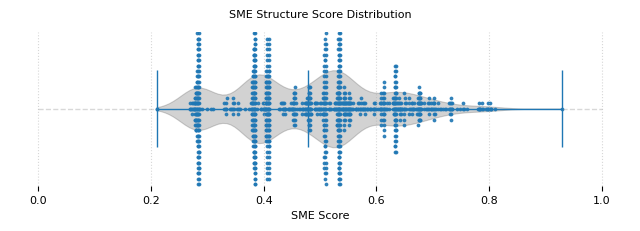

In [21]:
fig, axes = plt.subplots(
    1,1,
    figsize=(8,2),
    # gridspec_kw={"width_ratios": [7, 3]}   # 70/30 width split
)

options = {
    'dot_size': 3,
    'max_possible': 1.0,
    'cap_height': 0.5,
    'line_weight': 1,
    'show_global_median': False,
    'base_color': "#222222",
    'line_stat': "mean",
}

# axes = axes.flatten()
plots.plot_horizontal_violin_beeswarm_stacked(sme_structure_score, ax=axes
                                        , xlabel="SME Score"
                                        , title= f"SME Structure Score Distribution"
                                        ,**options
                                        )
fig.subplots_adjust(hspace=0.8)
plots.set_plot_font_styles(fig, axis_size=8, title_size=8, annotation_size=7)
plt.show()

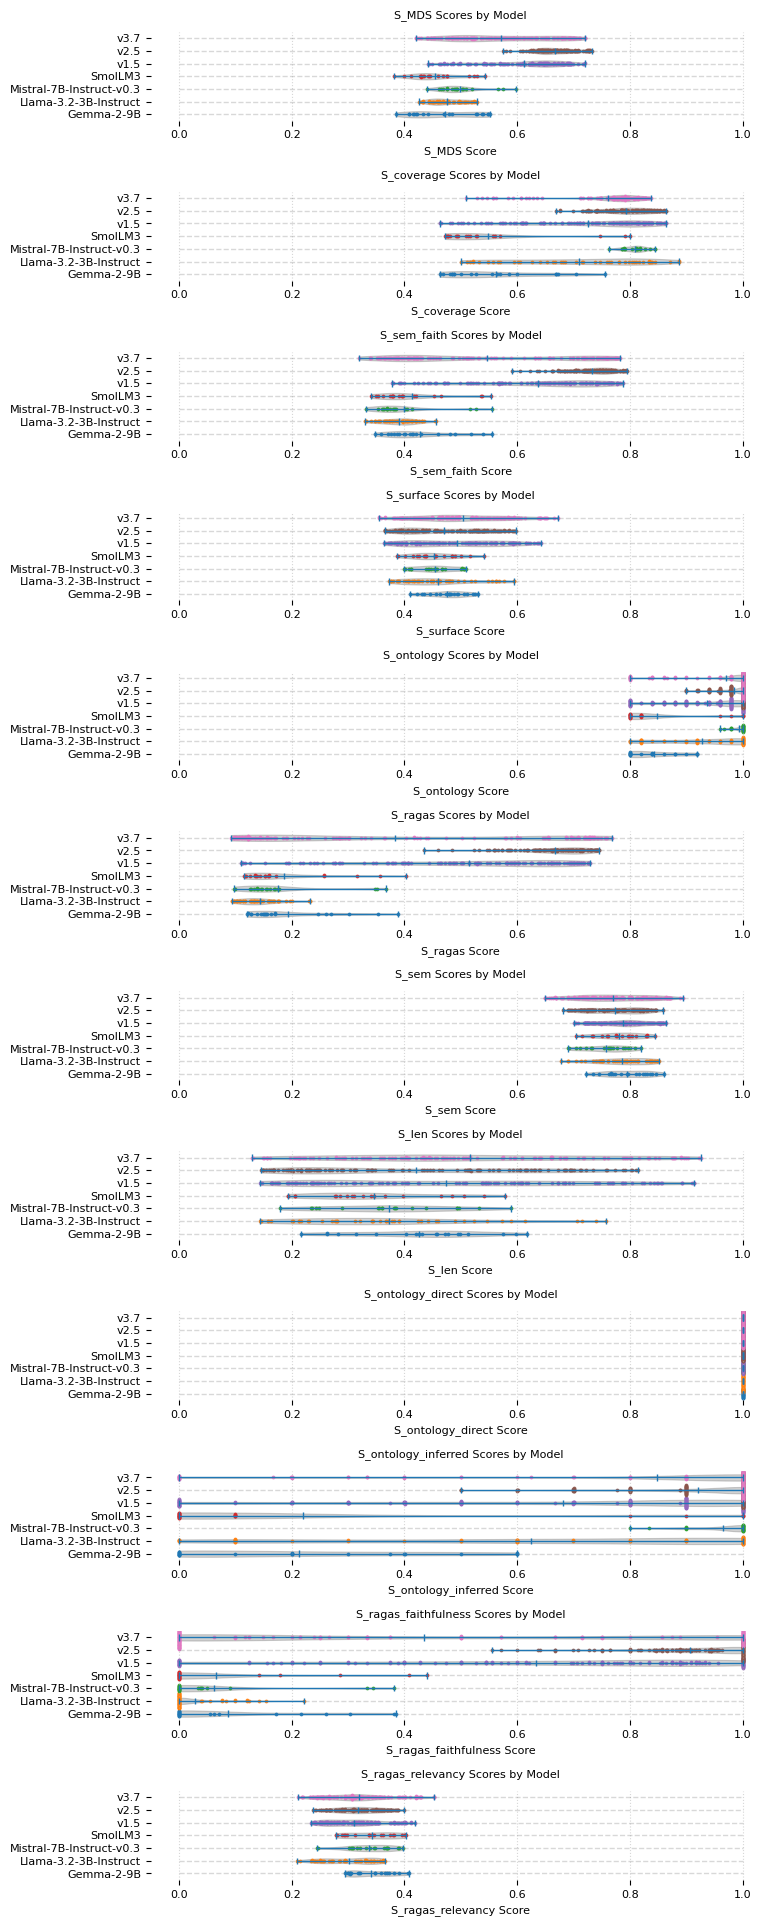

In [16]:
fig, axes = plt.subplots(
    12, 1,
    figsize=(8,24),
    # gridspec_kw={"width_ratios": [7, 3]}   # 70/30 width split
)

options = {
    'dot_size': 3,
    'max_possible': 1.0,
    'cap_height': 0.5,
    'line_weight': 1,
    'show_global_median': False,
    'base_color': "#222222",
    'line_stat': "mean",
    'percentile_clip': (5, 95)
}

axes = axes.flatten()
plots.plot_horizontal_violin_beeswarm_stacked(metric_dicts['S_MDS'], ax=axes[0]
                                        , xlabel="S_MDS Score"
                                        , title= f"S_MDS Scores by Model"
                                        ,**options
                                        )

plots.plot_horizontal_violin_beeswarm_stacked(metric_dicts['S_coverage'], ax=axes[1]
                                        , xlabel="S_coverage Score"
                                        , title= f"S_coverage Scores by Model"
                                        ,**options
                                        )
plots.plot_horizontal_violin_beeswarm_stacked(metric_dicts['S_sem_faith'], ax=axes[2]
                                        , xlabel="S_sem_faith Score"
                                        , title= f"S_sem_faith Scores by Model"
                                        ,**options
                                        )
plots.plot_horizontal_violin_beeswarm_stacked(metric_dicts['S_surface'], ax=axes[3]
                                        , xlabel="S_surface Score"
                                        , title= f"S_surface Scores by Model"
                                        ,**options
                                        )
plots.plot_horizontal_violin_beeswarm_stacked(metric_dicts['S_ontology'], ax=axes[4]
                                        , xlabel="S_ontology Score"
                                        , title= f"S_ontology Scores by Model"
                                        ,**options
                                        )
plots.plot_horizontal_violin_beeswarm_stacked(metric_dicts['S_ragas'], ax=axes[5]
                                        , xlabel="S_ragas Score"
                                        , title= f"S_ragas Scores by Model"
                                        ,**options
                                        )
plots.plot_horizontal_violin_beeswarm_stacked(metric_dicts['S_sem'], ax=axes[6]
                                        , xlabel="S_sem Score"
                                        , title= f"S_sem Scores by Model"
                                        ,**options
                                        )
plots.plot_horizontal_violin_beeswarm_stacked(metric_dicts['S_len'], ax=axes[7]
                                        , xlabel="S_len Score"
                                        , title= f"S_len Scores by Model"
                                        ,**options
                                        )
plots.plot_horizontal_violin_beeswarm_stacked(metric_dicts['S_ontology_direct'], ax=axes[8]
                                        , xlabel="S_ontology_direct Score"
                                        , title= f"S_ontology_direct Scores by Model"
                                        ,**options
                                        )
plots.plot_horizontal_violin_beeswarm_stacked(metric_dicts['S_ontology_inferred'], ax=axes[9]
                                        , xlabel="S_ontology_inferred Score"
                                        , title= f"S_ontology_inferred Scores by Model"
                                        ,**options
                                        )
plots.plot_horizontal_violin_beeswarm_stacked(metric_dicts['S_ragas_faithfulness'], ax=axes[10]
                                        , xlabel="S_ragas_faithfulness Score"
                                        , title= f"S_ragas_faithfulness Scores by Model"
                                        ,**options
                                        )   
plots.plot_horizontal_violin_beeswarm_stacked(metric_dicts['S_ragas_relevancy'], ax=axes[11]
                                        , xlabel="S_ragas_relevancy Score"
                                        , title= f"S_ragas_relevancy Scores by Model"
                                        ,**options
                                        )
fig.subplots_adjust(hspace=0.8)
plots.set_plot_font_styles(fig, axis_size=8, title_size=8, annotation_size=7)
plt.show()

NameError: name 'metric_dicts' is not defined

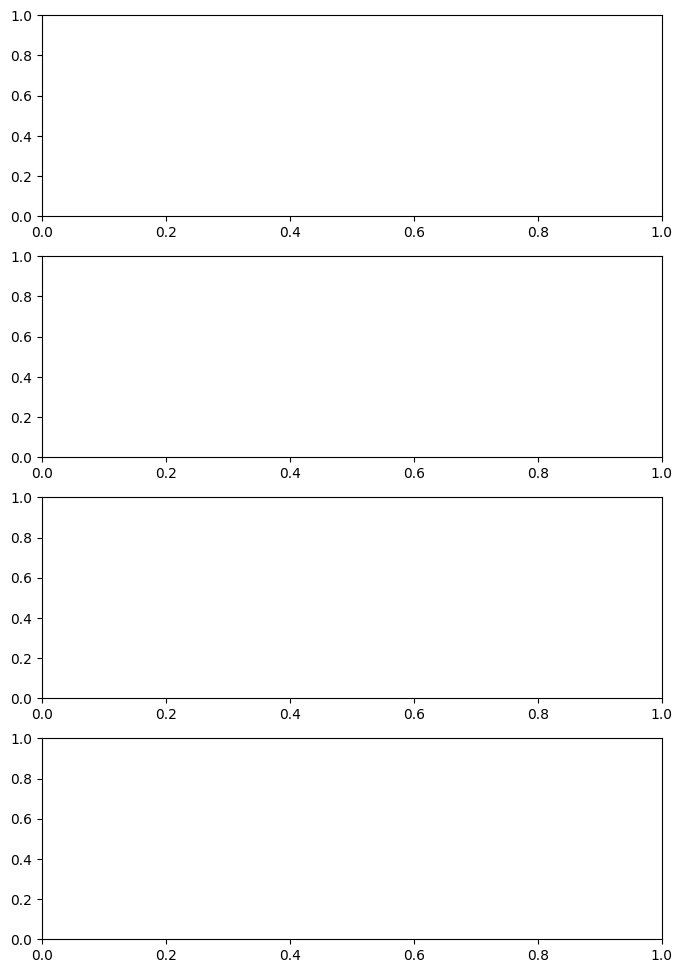

In [14]:
fig, axes = plt.subplots(
    4, 1,
    figsize=(8,12),
    # gridspec_kw={"width_ratios": [7, 3]}   # 70/30 width split
)



axes = axes.flatten()
plots.plot_horizontal_violin_beeswarm_stacked(metric_dicts['S_MDS'], ax=axes[0]
                                        , xlabel="S_MDS Score"
                                        , title= f"S_MDS Scores by Model"
                                        ,**options
                                        )

plots.plot_horizontal_violin_beeswarm_stacked(metric_dicts['S_coverage'], ax=axes[1]
                                        , xlabel="S_coverage Score"
                                        , title= f"S_coverage Scores by Model"
                                        ,**options
                                        )
plots.plot_horizontal_violin_beeswarm_stacked(metric_dicts['S_sem_faith'], ax=axes[2]
                                        , xlabel="S_sem_faith Score"
                                        , title= f"S_sem_faith Scores by Model"
                                        ,**options
                                        )
plots.plot_horizontal_violin_beeswarm_stacked(metric_dicts['S_surface'], ax=axes[3]
                                        , xlabel="S_surface Score"
                                        , title= f"S_surface Scores by Model"
                                        ,**options
                                        )

fig.subplots_adjust(hspace=0.8)
plots.set_plot_font_styles(fig, axis_size=8, title_size=8, annotation_size=7)
plt.show()




In [13]:
def clean_vals(vals, require_min_two=True, drop_constant=True):
    """Clean a numpy array for KDE/violinplot use."""
    arr = np.asarray(vals, dtype=float)

    # Remove nan/inf
    arr = arr[np.isfinite(arr)]

    if arr.size == 0:
        return np.array([])

    # Require at least 2 points for violin
    if require_min_two and arr.size < 2:
        return np.array([])

    # Drop constant (zero-variance) groups, if desired
    if drop_constant and np.allclose(arr, arr[0]):
        return np.array([])

    return arr


In [12]:
baseline_scores_sql = """SELECT * FROM SCORES4"""
baseline_scores_df = pd.read_sql(baseline_scores_sql, engine)
baseline_scores_df = add_pillars_and_mds(baseline_scores_df)
baseline_metric_dicts = {name: {} for name in metric_names}
for model, g in baseline_scores_df.groupby("model_name"):
    for name in metric_names:
        if name in g.columns:
            raw_vals = g[name].tolist()
            cleaned_vals = clean_vals(raw_vals)

            baseline_metric_dicts[name][model] = cleaned_vals

NameError: name 'clean_vals' is not defined

NameError: name 'baseline_metric_dicts' is not defined

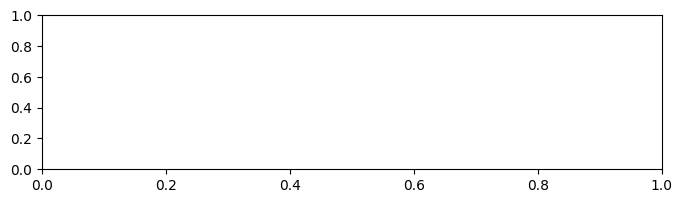

In [11]:
fig, axes = plt.subplots(
    1, 1,
    figsize=(8,2),
)

options = {
    'dot_size': 3,
    'max_possible': 1,
    'min_possible': 0,
    'cap_height': 0.5,
    'line_weight': 1,
    'show_global_median': False,
    'base_color': "#222222",
    'line_stat': "mean",
    'percentile_clip': (5, 95)
}

# axes = axes.flatten()
plots.plot_horizontal_violin_beeswarm_stacked(baseline_metric_dicts['S_MDS'], ax=axes#[0]
                                        , xlabel="S_MDS Score"
                                        , title= f""
                                        ,**options
                                        )
# plots.plot_horizontal_violin_beeswarm_stacked(baseline_metric_dicts['S_surface'], ax=axes#[1]
#                                         , xlabel="S_surface Score"
#                                         , title= f""
#                                         ,**options
#                                         )



# plots.plot_horizontal_violin_beeswarm_stacked(baseline_metric_dicts['S_MDS'], ax=axes#[0]
#                                         , xlabel="S_MDS Scores by Model"
#                                         , title= f""
#                                         ,**options
#                                         )

# plots.plot_horizontal_violin_beeswarm_stacked(baseline_metric_dicts['S_coverage'], ax=axes[1]
#                                         , xlabel="S_coverage Score"
#                                         , title= f"S_coverage Scores by Model"
#                                         ,**options
#                                         )
# plots.plot_horizontal_violin_beeswarm_stacked(baseline_metric_dicts['S_ragas_relevancy'], ax=axes#[0]
#                                         , xlabel="S_ragas_relevancy Score"
#                                         , title= f"S_ragas_relevancy Scores by Model"
#                                         ,**options
#                                         )

# plots.plot_horizontal_violin_beeswarm_stacked(baseline_metric_dicts['S_spacy'], ax=axes#[1]
#                                         , xlabel="S_spacy Scores by Model Score"
#                                         , title= f""
#                                         ,**options
#                                         )


fig.subplots_adjust(hspace=0.8)
plots.set_plot_font_styles(fig, axis_size=8, title_size=8, annotation_size=7)
plt.show()




The MDS framework was not used to select the baseline model because it was developed later in the project to evaluate ontology-aware and KG-aware generations. At the time of initial model selection, the evaluation criteria had to be model-agnostic and independent of ontology coverage, keyword matching, and RAG faithfulness—metrics that are meaningless or misleading when the model has no access to ontology or knowledge-graph context. Using MDS would have introduced bias toward models that hallucinate structure or verbosity, rather than models that generate faithful, concise policy text.

Therefore, the baseline model was selected using semantic, lexical, and structural fidelity metrics only, ensuring the evaluation reflected true generation quality rather than inflated coverage signals.

In [ ]:
import numpy as np
import pandas as pd

def summarize_baseline(df, metric_names):
    rows = []
    
    for metric in metric_names:
        if metric not in df.columns:
            continue
        
        for model, g in df.groupby("model_name"):
            vals = g[metric].dropna().astype(float).values
            
            rows.append({
                "model": model,
                "metric": metric,
                "mean": vals.mean(),
                "median": np.median(vals),
                "std": vals.std(ddof=1),
                "p25": np.percentile(vals, 25),
                "p75": np.percentile(vals, 75),
                "n": len(vals),
            })
    
    return pd.DataFrame(rows)

summary_df = summarize_baseline(baseline_scores_df, metric_names)
median_table = (
    summary_df
    .pivot(index="model", columns="metric", values="median")
    .reindex(columns=metric_names)   # keep your order
    .round(3)
)
median_table = median_table.sort_values("S_MDS", ascending=False)

median_table



In [ ]:
baseline_scores_df

In [ ]:
import numpy as np
import pandas as pd

# Metrics that fairly evaluate baseline models (no ontology bias)
correctness_metrics = [
    "S_lex",
    "S_len",
    "S_sem",
    "S_sem_faith",
    "S_surface",
]

def summarize_baseline_correctness_by_framework(df, metrics):
    rows = []
    
    for metric in metrics:
        if metric not in df.columns:
            continue

        for (model_name, source_framework), g in df.groupby(["model_name", "source_framework"]):
            vals = (
                g[metric]
                .replace([np.inf, -np.inf], np.nan)
                .dropna()
                .astype(float)
                .values
            )

            rows.append({
                "source_framework": source_framework,
                "model_name": model_name,
                "metric": metric,
                "mean": vals.mean(),
                "median": np.median(vals),
                "std": vals.std(ddof=1),
                "p25": np.percentile(vals, 25),
                "p75": np.percentile(vals, 75),
                "n": len(vals),
            })
    
    return pd.DataFrame(rows)


def summarize_baseline_correctness(df, metrics):
    rows = []
    
    for metric in metrics:
        if metric not in df.columns:
            continue

        for model, g in df.groupby(["model_name"]):
            vals = (
                g[metric]
                .replace([np.inf, -np.inf], np.nan)
                .dropna()
                .astype(float)
                .values
            )
            
            rows.append({
                "model": model,
                "metric": metric,
                "mean": vals.mean(),
                "median": np.median(vals),
                "std": vals.std(ddof=1),
                "p25": np.percentile(vals, 25),
                "p75": np.percentile(vals, 75),
                "n": len(vals),
            })
    
    return pd.DataFrame(rows)

# Build the summary
correctness_summary_df = summarize_baseline_correctness(
    baseline_scores_df,
    correctness_metrics
)

# Pivot into a clean table (medians by model)
correctness_median_table = (
    correctness_summary_df
    .pivot(index="model", columns="metric", values="median")
    .reindex(columns=correctness_metrics)
    .round(3)
)

correctness_median_table


In [ ]:
# Build the summary
correctness_summary_df = summarize_baseline_correctness_by_framework(
    baseline_scores_df,
    correctness_metrics
)

# Pivot into a clean table (medians by model & framework)
correctness_median_table = (
    correctness_summary_df
    .pivot_table(
        index=["source_framework", "model_name"],
        columns="metric",
        values="median"
    )
    .reindex(columns=correctness_metrics)
    .round(3)
    .sort_index()
)

correctness_median_table

In [ ]:
correctness_summary_df

The summary table reports the median values for core correctness metrics—semantic similarity (BGE), semantic faithfulness, lexical alignment, length coherence, and surface-form match—for each baseline model. These metrics isolate the model’s ability to faithfully and accurately restate policy text without ontology scaffolding or contextual augmentation. By excluding ontology, keyword, and RAG-based scores that artificially reward verbosity or hallucinations, the table provides a fair and direct comparison of baseline model behavior.

Across these correctness-only metrics, Gemma-2-9B demonstrates the strongest and most stable semantic alignment and surface quality, validating its selection as the foundation model for all subsequent ontology-enhanced and LoRA-tuned versions.

In [ ]:
# plots.copy_fig_to_clipboard(fig)